In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [3]:
df=pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
 print(df.shape)

(10000, 14)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Exited'].value_counts()


Exited
0    7963
1    2037
Name: count, dtype: int64

In [14]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [16]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [17]:
df.drop(columns=['RowNumber','Surname','CustomerId'],inplace=True)

In [18]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [21]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [22]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [23]:
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

In [24]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X=df.drop(columns=['Exited'])
y=df['Exited']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [27]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [28]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [29]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [30]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [31]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [50]:
model = Sequential()

# model.add(Dense(3,activation='sigmoid',input_dim=11)) # hidden layer
# model.add(Dense(1,activation='sigmoid')) # output layer

# model = Sequential()
# Sequential ka matlab hai layers ko ek ke baad ek sequential order mein stack karna.
# 3-->number of neurons in layer
# output layer me ek hi neuron hoga hamesha

# 2nd try with different architecture #
# 2 hiiden layer
# 11 neurons in hidden layer sam as input dimentions
# different activation function
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [51]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [54]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2) 
# vali_split sath me accuracy batayega 80 pecent ka bhi 20 percetn kam krke unpe test arega live

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7102 - loss: 0.5836 - val_accuracy: 0.8069 - val_loss: 0.4806
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8086 - loss: 0.4516 - val_accuracy: 0.8125 - val_loss: 0.4397
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8136 - loss: 0.4266 - val_accuracy: 0.8194 - val_loss: 0.4269
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8184 - loss: 0.4170 - val_accuracy: 0.8231 - val_loss: 0.4192
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8247 - loss: 0.4086 - val_accuracy: 0.8263 - val_loss: 0.4119
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8303 - loss: 0.3995 - val_accuracy: 0.8331 - val_loss: 0.4017
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8384 - loss: 0.3898 - val_accuracy: 0.8394 - val_loss: 0.3914
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8445 - loss: 0.3801 - val_accu

In [55]:
model.layers[0].get_weights()

[array([[ 0.02551107, -0.08368865, -0.08633585,  0.19009754,  0.00449221,
          0.253493  , -0.00635892, -0.20757526,  0.01745845, -0.00713328,
          0.1167284 ],
        [-1.0756803 ,  0.4942141 , -0.3355006 ,  0.26556662, -0.06193016,
          0.70239997, -0.46300247, -0.01312969, -0.975923  , -0.00787844,
         -1.0283092 ],
        [-0.15152183, -0.14480492,  0.3521951 , -0.08737401, -0.06316806,
         -0.18178979, -0.17084119, -0.15624878, -0.05816793, -0.05408333,
         -0.04970585],
        [ 0.32866433, -0.0978678 ,  0.24147378,  0.15532072, -0.59074146,
         -0.49650526, -0.3149439 , -0.36829853,  0.11665548,  0.23433985,
         -0.4602777 ],
        [ 0.1635188 ,  0.32831421,  0.23632306,  0.7364582 , -0.61493343,
          0.17280787,  0.8418177 , -1.0069126 ,  0.03360083,  0.9901071 ,
          0.21738715],
        [-0.34027046,  0.25938907,  0.50022316,  0.01204424, -0.05984369,
         -0.04138041, -0.11375951, -0.17625152, -0.2512011 ,  0.0027935

In [56]:
model.layers[1].get_weights()

[array([[-0.9978886 , -0.24607787,  0.757875  ,  0.04057531, -0.1219523 ,
          0.48818144,  0.3547853 , -0.07814697, -0.06301125, -0.05482166,
         -0.35810986],
        [ 0.18113641, -0.77420086, -0.8648703 ,  0.2660201 , -0.69647026,
         -0.06184597, -0.32454553,  0.5594319 ,  0.0085962 ,  0.04822906,
         -0.29096445],
        [-0.05310209, -0.05246496,  0.1184713 , -0.17404772,  0.6235504 ,
          0.09999939, -0.17225336,  0.40577725,  0.4526079 , -0.02960242,
         -0.5863119 ],
        [ 0.7847862 ,  0.5786213 , -0.49236524,  0.4424399 , -0.64011675,
         -0.30018076,  0.00403132,  0.05036819, -0.01544912,  0.00501037,
          0.25898066],
        [ 0.27548313,  0.4546069 , -0.13936703,  0.30157712, -0.35294238,
         -0.28663272, -1.0636328 ,  0.5830416 , -1.0592493 ,  0.76966286,
          0.30953264],
        [-0.05887606,  0.4691444 , -0.53681064,  0.36735472,  0.4548379 ,
          0.21502073, -0.3017112 ,  0.5733896 , -0.45739335, -0.0573646

In [57]:
model.layers[2].get_weights()

[array([[ 1.1875653 ],
        [ 1.1357483 ],
        [ 1.4638277 ],
        [-0.39253783],
        [-0.41756228],
        [-0.8357128 ],
        [ 1.5724714 ],
        [-0.68750626],
        [ 0.8912939 ],
        [ 0.53151757],
        [ 0.67030627]], dtype=float32),
 array([-0.23629732], dtype=float32)]

In [58]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [59]:
y_pred=np.where(y_log>0.5,1,0)

In [60]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.859

In [61]:
import matplotlib.pyplot as plt

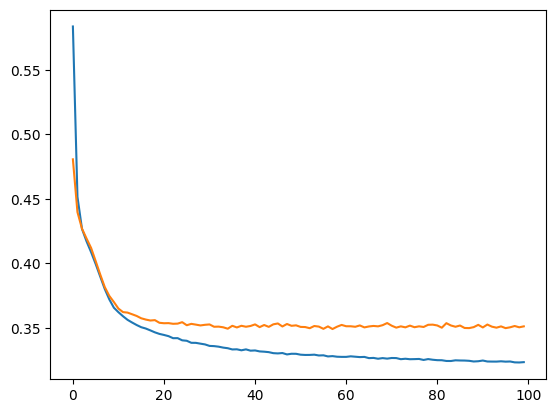

In [62]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

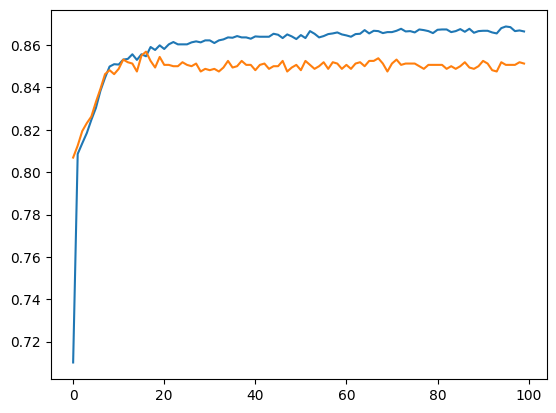

In [63]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()